In [1]:
# ============================================================
# ETAPA 1 - CARGA, LIMPIEZA BÁSICA Y NUEVA AGRUPACIÓN CATEGÓRICA
# Objetivo:
#   - Cargar el Excel
#   - Normalizar nombres de columnas
#   - Eliminar TCOD, SCOD y VFA inicial
#   - Crear categorías:
#       * Sustrato_base
#       * TipoInoculo_cat
#       * FuenteInoculo_cat
#   - Ver distribuciones
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# ---- 1.1 Cargar dataset desde Drive ----
ruta = "/content/drive/MyDrive/Universidad_y_Trabajo/Tesis/Data_Raw/Dataset_Limpio_RF.xlsx"
df = pd.read_excel(ruta)

print("✔ Dataset cargado. Shape original:", df.shape)

# ---- 1.2 Limpiar nombres de columnas ----
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(r"\s+", " ", regex=True)

print("\n✔ Nombres de columnas normalizados.")
print("Número de columnas:", len(df.columns))
print("Algunas columnas:", df.columns[:10].tolist())

# ---- 1.3 Eliminar columnas químicas que NO queremos usar como entrada ----
cols_drop = [
    "Demanda Química de Oxígeno Total (TCOD) [mg/L]",
    "Demanda Química de Oxígeno Soluble (SCOD) [mg/L]",
    "Ácidos Grasos Volátiles Iniciales (VFA) [mg/L]"
]

cols_drop_presentes = [c for c in cols_drop if c in df.columns]
df = df.drop(columns=cols_drop_presentes)

print("\n✔ Columnas removidas (si estaban):", cols_drop_presentes)
print("Shape después de eliminar columnas:", df.shape)

# ============================================================
# 1.4 FUNCIONES DE AGRUPACIÓN
#   - Sustrato_base: identifica el/los sustratos principales
#   - TipoInoculo_cat: naturaleza biológica + configuración
#   - FuenteInoculo_cat: sector/instalación
# ============================================================

def _norm(x):
    """Normaliza texto: str + lower + strip. Maneja NaN."""
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def _has_any(text, keywords):
    return any(k in text for k in keywords)

def agrupar_sustrato_base(x):
    """
    NUEVO: Agrupa 'Sustrato (Mezcla)' por sustrato(s) orgánico(s) principales.
    Ignora aditivos/condiciones (biochar, FeCl3, bacterias, control, alta carga, etc.)

    Categorías:
      - BSG
      - BSY
      - BWW
      - Lodos
      - Mezcla_BSG_Lodos
      - Mezcla_BSG_BWW
      - Mezcla_BWW_BSY
      - Otros
    """
    t = _norm(x)

    # Palabras clave por "familia" (lo más estable)
    kw_bsg = ["bsg", "bagazo", "spent grain", "bagazo de malta", "malta"]
    kw_bsy = ["bsy", "spent yeast", "brewery spent yeast", "levadura"]
    kw_bww = ["bww", "brewery wastewater", "aguas residuales", "bwws", "wws", "ww "]
    kw_lodos = ["sludge", "lodo", "lodos"]

    has_bsg   = _has_any(t, kw_bsg)
    has_bsy   = _has_any(t, kw_bsy)
    has_bww   = _has_any(t, kw_bww)
    has_lodos = _has_any(t, kw_lodos)

    # Mezclas principales (prioridad a co-digestión)
    if has_bsg and has_lodos:
        return "Mezcla_BSG_Lodos"
    if has_bsg and has_bww:
        return "Mezcla_BSG_BWW"
    if has_bww and has_bsy:
        return "Mezcla_BWW_BSY"

    # Mono-sustrato dominante
    if has_bsg:
        return "BSG"
    if has_bsy:
        return "BSY"
    if has_bww:
        return "BWW"
    if has_lodos:
        return "Lodos"

    return "Otros"


def agrupar_tipo_inoculo_cat(x):
    """
    NUEVO: Agrupa 'Tipo de Inóculo' por naturaleza/configuración.
    Categorías:
      - Digestato
      - Lodo_anaerobio
      - Granular_UASB
      - Mixto_Modificado
      - Otros
    """
    t = _norm(x)

    # Mixtos / modificados primero
    if "uasb" in t and ("mix" in t or "bacteria" in t or "+" in t):
        return "Mixto_Modificado"

    # Granular UASB
    if "uasb" in t or "granular" in t:
        return "Granular_UASB"

    # Digestato
    if "digestat" in t or "digestato" in t:
        return "Digestato"

    # Lodo anaerobio / sludge
    if "sludge" in t or "lodo" in t:
        return "Lodo_anaerobio"

    return "Otros"


def agrupar_fuente_inoculo_cat(x):
    """
    NUEVO: Agrupa 'Fuente del Inóculo' por tipo de instalación / sector.
    Categorías:
      - WWTP_Municipal
      - Industrial_Cervecera
      - Industrial_No_Cervecera
      - Agricola_Lechero
      - Planta_Biogas
      - Otros
    """
    t = _norm(x)

    # WWTP / PTAR / municipal
    if _has_any(t, ["wwtp", "ptar", "mnwwrp", "municipal", "planta de aguas servidas"]):
        return "WWTP_Municipal"

    # Cervecera
    if _has_any(t, ["brewery", "cervecera", "cerveceria", "laško", "st. george", "heineken", "ptar cervecera", "wwtp cervecera"]):
        return "Industrial_Cervecera"

    # Agrícola / lechero
    if _has_any(t, ["lechero", "biodigestor lechero", "reactor anaerobio lechero", "estiércol", "estiercol"]):
        return "Agricola_Lechero"

    # Planta de biogás
    if _has_any(t, ["biogas plant", "planta biogás", "planta biogas"]):
        return "Planta_Biogas"

    # Industrial general (no cervecera)
    if _has_any(t, ["industrial", "digestor industrial", "bio-wat", "coca-cola"]):
        return "Industrial_No_Cervecera"

    # Digestor anaerobio previo / co-digestión OFMSW (si no cayó antes)
    if _has_any(t, ["digestor", "ofmsw"]):
        return "Industrial_No_Cervecera"

    return "Otros"

# ============================================================
# 1.5 CREAR NUEVAS COLUMNAS AGRUPADAS
# ============================================================

cols_req = ["Sustrato (Mezcla)", "Tipo de Inóculo", "Fuente del Inóculo"]
faltan = [c for c in cols_req if c not in df.columns]

if faltan:
    raise KeyError(f"⚠ No se encontraron estas columnas requeridas en el dataset: {faltan}")

df["Sustrato_base"]      = df["Sustrato (Mezcla)"].apply(agrupar_sustrato_base)
df["TipoInoculo_cat"]    = df["Tipo de Inóculo"].apply(agrupar_tipo_inoculo_cat)
df["FuenteInoculo_cat"]  = df["Fuente del Inóculo"].apply(agrupar_fuente_inoculo_cat)

print("\n✔ Columnas categóricas creadas: Sustrato_base, TipoInoculo_cat, FuenteInoculo_cat")

# ============================================================
# 1.6 VER DISTRIBUCIONES DE LAS NUEVAS CATEGORÍAS
# ============================================================

print("\n📌 Distribución Sustrato_base:")
print(df["Sustrato_base"].value_counts())

print("\n📌 Distribución TipoInoculo_cat:")
print(df["TipoInoculo_cat"].value_counts())

print("\n📌 Distribución FuenteInoculo_cat:")
print(df["FuenteInoculo_cat"].value_counts())


Mounted at /content/drive
✔ Dataset cargado. Shape original: (104, 38)

✔ Nombres de columnas normalizados.
Número de columnas: 38
Algunas columnas: ['% Remoción TVS', 'Agitación [rpm]', 'Alcalinidad [mg/L]', 'Alcalinidad final [mg CaCO₃/L)', 'Contenido Lignina [%]', 'Contenido de Fibra (celulosa + hemicelulosa) [% TS]', 'Demanda Química de Oxígeno Soluble (SCOD) [mg/L]', 'Demanda Química de Oxígeno Total (TCOD) [mg/L]', 'Experimento', 'Grado de Conversión [%]']

✔ Columnas removidas (si estaban): ['Demanda Química de Oxígeno Total (TCOD) [mg/L]', 'Demanda Química de Oxígeno Soluble (SCOD) [mg/L]', 'Ácidos Grasos Volátiles Iniciales (VFA) [mg/L]']
Shape después de eliminar columnas: (104, 35)

✔ Columnas categóricas creadas: Sustrato_base, TipoInoculo_cat, FuenteInoculo_cat

📌 Distribución Sustrato_base:
Sustrato_base
BSG                 54
Mezcla_BSG_Lodos    17
BWW                  9
Mezcla_BSG_BWW       8
BSY                  6
Otros                4
Lodos                3
Mezcla_BW

In [2]:
# ============================================================
# LISTAR TODAS LAS CATEGORÍAS ORIGINALES (SIN AGRUPAR)
# ============================================================

cols_interes = [
    "Sustrato (Mezcla)",
    "Tipo de Inóculo",
    "Fuente del Inóculo"
]

for col in cols_interes:
    print("\n" + "="*60)
    print(f"📌 Columna: {col}")
    print(f"Cantidad de valores únicos: {df[col].nunique()}")
    print("-"*60)

    valores = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .sort_values()
        .unique()
    )

    for v in valores:
        print(f"- {v}")



📌 Columna: Sustrato (Mezcla)
Cantidad de valores únicos: 71
------------------------------------------------------------
- 100 % sludge
- 100% BSG (bagazo cervecero)
- 100:0 (CM)
- 25 % sludge + 75 % BSG
- 50 % BSG + 50 % PM + BWWS
- 50 % Sludge + 50 % BSG
- 50 % sludge + 50 % BSG
- 60 % BSG + 40 % PM + BWWS
- 60 % BSG + 40 % PM + BWWS + 15 mg/L FeCl₃
- 68:32 (CM:RY)
- 75 % Sludge + 25 % BSG
- 75 % sludge + 25 % BSG
- 78:22 (CM:RY)
- 88:12 (CM:RY)
- Aguas residuales cerveceras + estiércol lácteo
- BSG
- BSG (25%) + Inóculo (45%) + Agua (30%)
- BSG (control sin biochar)
- BSG + 1 % BC300
- BSG + 10% BC-Oat hulls
- BSG + 10% BC-Willow
- BSG + 2% BC-Pine
- BSG + 3 % BC450
- BSG + 3 % BC600
- BSG + 50% BC-Corncob
- BSG + Agua
- BSG + BWWS
- BSG + BWWS + 10 mg/L FeCl₃
- BSG + BWWS + 15 mg/L FeCl₃
- BSG + C. cellulovorans
- BSG + F. succinogenes
- BSG + P. xylanivorans
- BSG + co-cultivo
- BSG + medio
- BSG sin biochar
- BSY (two-stage)
- BWW + 1 % Yeast
- BWW + 11 % Yeast
- BWW + 6 % Yeast

In [3]:
# ============================================================
# ETAPA 2 — Definir variables de entrada (X) y salida (Y)
# ============================================================

print("\n=== ETAPA 2: Construcción de X y Y ===")

# ---- 2.1 Definir columnas de salida ----
Y_cols = [
    "Producción total biogás [mL/g VS]",
    "% Remoción TVS",
    "Porcentaje de CH4 en biogás (%)"
]

print("\n✔ Columnas Y seleccionadas:")
for c in Y_cols:
    print(" -", c)

# ---- 2.2 Definir columnas de entrada (X) ----
X_cols = [
    "Sustrato_base",
    "TipoInoculo_cat",
    "FuenteInoculo_cat",
    "Volumen del reactor [mL]",
    "Volumen trabajo reactor [mL]",
    "Inóculo [mL]",
    "TS inicial (%)",
    "Sólidos Totales (TS) [g/L]",
    "TVS inicial (%)",
    "Sólidos Volátiles Totales inicial (TVS) [g/L]",
    "Relación C/N",
    "Contenido Lignina [%]",
    "Contenido de Fibra (celulosa + hemicelulosa) [% TS]",
    "NH3 [mg/L]",
    "Temperatura [°C]",
    "HRT [días]",
    "pH inicial",
    "Alcalinidad [mg/L]",
    "Velocidad de Carga Orgánica (OLR) [gTVS/L*d]",
    "Agitación [rpm]"
]

# ---- 2.3 Validar que todas las columnas existan en el dataset ----
missing_X = [c for c in X_cols if c not in df.columns]
missing_Y = [c for c in Y_cols if c not in df.columns]

if missing_X:
    print("\n❌ ERROR: Faltan columnas en X:", missing_X)
    raise KeyError(f"Columnas faltantes en X: {missing_X}")

if missing_Y:
    print("\n❌ ERROR: Faltan columnas en Y:", missing_Y)
    raise KeyError(f"Columnas faltantes en Y: {missing_Y}")

print("\n✔ Todas las columnas X e Y existen en el dataset.")

# ---- 2.4 Construcción final de matrices X e Y ----
X = df[X_cols].copy()
Y = df[Y_cols].copy()

print("\n✔ X e Y construidos con éxito.")
print("   - X shape:", X.shape)
print("   - Y shape:", Y.shape)

print("\n=== ETAPA 2 COMPLETADA ===")



=== ETAPA 2: Construcción de X y Y ===

✔ Columnas Y seleccionadas:
 - Producción total biogás [mL/g VS]
 - % Remoción TVS
 - Porcentaje de CH4 en biogás (%)

✔ Todas las columnas X e Y existen en el dataset.

✔ X e Y construidos con éxito.
   - X shape: (104, 20)
   - Y shape: (104, 3)

=== ETAPA 2 COMPLETADA ===


In [4]:
# ============================================================
# ETAPA 3 — División Train/Test + Identificación de columnas
# ============================================================

print("\n=== ETAPA 3: Train/Test Split y Definición de Columnas ===")

from sklearn.model_selection import train_test_split

# 3.1 División Train/Test (80% - 20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

print("\n✔ División realizada:")
print("   - X_train:", X_train.shape)
print("   - X_test :", X_test.shape)
print("   - Y_train:", Y_train.shape)
print("   - Y_test :", Y_test.shape)


# 3.2 Identificar columnas categóricas y numéricas
cat_cols = ["Sustrato_base", "TipoInoculo_cat", "FuenteInoculo_cat"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("\n✔ Columnas categóricas:", cat_cols)
print("\n✔ Columnas numéricas (%d):" % len(num_cols))
for c in num_cols:
    print("   -", c)

print("\n=== ETAPA 3 COMPLETADA ===")



=== ETAPA 3: Train/Test Split y Definición de Columnas ===

✔ División realizada:
   - X_train: (83, 20)
   - X_test : (21, 20)
   - Y_train: (83, 3)
   - Y_test : (21, 3)

✔ Columnas categóricas: ['Sustrato_base', 'TipoInoculo_cat', 'FuenteInoculo_cat']

✔ Columnas numéricas (17):
   - Volumen del reactor [mL]
   - Volumen trabajo reactor [mL]
   - Inóculo [mL]
   - TS inicial (%)
   - Sólidos Totales (TS) [g/L]
   - TVS inicial (%)
   - Sólidos Volátiles Totales inicial (TVS) [g/L]
   - Relación C/N
   - Contenido Lignina [%]
   - Contenido de Fibra (celulosa + hemicelulosa) [% TS]
   - NH3 [mg/L]
   - Temperatura [°C]
   - HRT [días]
   - pH inicial
   - Alcalinidad [mg/L]
   - Velocidad de Carga Orgánica (OLR) [gTVS/L*d]
   - Agitación [rpm]

=== ETAPA 3 COMPLETADA ===


In [5]:
# ============================================================
# ETAPA 4 — Construcción del Preprocesador
# ============================================================

print("\n=== ETAPA 4: Construcción del Preprocesador ===")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ---- 4.1 Definir columnas categóricas ----
cat_cols = [
    "Sustrato_base",
    "TipoInoculo_cat",
    "FuenteInoculo_cat"
]

num_cols = [c for c in X.columns if c not in cat_cols]

# ---- 4.2 OneHotEncoder ----
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# ---- 4.3 ColumnTransformer ----
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

print("\n✔ Preprocesador creado con éxito.")
print("   - OneHot aplicado a:", cat_cols)
print("   - Variables numéricas pasan directo:", len(num_cols))

print("\n=== ETAPA 4 COMPLETADA ===")



=== ETAPA 4: Construcción del Preprocesador ===

✔ Preprocesador creado con éxito.
   - OneHot aplicado a: ['Sustrato_base', 'TipoInoculo_cat', 'FuenteInoculo_cat']
   - Variables numéricas pasan directo: 17

=== ETAPA 4 COMPLETADA ===


In [6]:
# ============================================================
# ETAPA 5 — Entrenar Modelo 1 (Random Forest)
# Variable objetivo: Producción total biogás [mL/g VS]
# (VERSIÓN MEJORADA, SIN TOCAR ETAPAS ANTERIORES)
# ============================================================

print("\n=== ETAPA 5: Entrenamiento del Modelo 1 — Producción total biogás ===")

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# 5.1 Definir el target por nombre
# ------------------------------------------------------------
y_col = "Producción total biogás [mL/g VS]"
y1_train = Y_train[y_col]
y1_test  = Y_test[y_col]

# ------------------------------------------------------------
# 5.2 Modelo un poco más estable (reduce varianza)
# ------------------------------------------------------------
rf1 = RandomForestRegressor(
    n_estimators=800,   # más árboles = predicción más estable
    random_state=42,
    n_jobs=-1
)

model1_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf1)
])

# ------------------------------------------------------------
# 5.3 Entrenar
# ------------------------------------------------------------
model1_pipeline.fit(X_train, y1_train)

# ------------------------------------------------------------
# 5.4 Predicciones y métricas
# ------------------------------------------------------------
y1_pred = model1_pipeline.predict(X_test)

mae  = mean_absolute_error(y1_test, y1_pred)
rmse = np.sqrt(mean_squared_error(y1_test, y1_pred))
r2   = r2_score(y1_test, y1_pred)

print("\n📌 RESULTADOS — Modelo 1 (Producción total biogás)")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

# ------------------------------------------------------------
# 5.5 Diagnóstico del warning (sin cambiar el pipeline)
#     Detecta categorías en test que no estén en train
# ------------------------------------------------------------
print("\n🔎 Chequeo de categorías desconocidas (test vs train):")
for col in cat_cols:
    train_cats = set(X_train[col].astype(str).unique())
    test_cats  = set(X_test[col].astype(str).unique())
    unseen = sorted(list(test_cats - train_cats))
    if unseen:
        print(f"⚠ {col}: categorías en test no vistas en train -> {unseen}")
    else:
        print(f"✔ {col}: sin categorías nuevas en test")

print("\n=== ETAPA 5 COMPLETADA ===")



=== ETAPA 5: Entrenamiento del Modelo 1 — Producción total biogás ===

📌 RESULTADOS — Modelo 1 (Producción total biogás)
MAE : 66.654
RMSE: 113.624
R²  : 0.667

🔎 Chequeo de categorías desconocidas (test vs train):
✔ Sustrato_base: sin categorías nuevas en test
✔ TipoInoculo_cat: sin categorías nuevas en test
✔ FuenteInoculo_cat: sin categorías nuevas en test

=== ETAPA 5 COMPLETADA ===


In [7]:
# ============================================================
# ETAPA 6 — Optimización del Modelo 1 (GridSearchCV)
# Target: Producción total biogás [mL/g VS]
# (versión más pulida, misma lógica)
# ============================================================

print("\n=== ETAPA 6: Optimización del Modelo 1 — Producción total biogás ===")

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 6.0 Definir target por nombre
# ------------------------------------------------------------
y_col = "Producción total biogás [mL/g VS]"
y1_train = Y_train[y_col]
y1_test  = Y_test[y_col]

print(f"\n✔ Target seleccionado: {y_col}")
print("   - y_train shape:", y1_train.shape)
print("   - y_test shape :", y1_test.shape)

# ------------------------------------------------------------
# 6.1 Pipeline base (preprocesamiento + modelo)
# ------------------------------------------------------------
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_base)
])

# ------------------------------------------------------------
# 6.2 Grilla de hiperparámetros (acotada, apropiada para dataset chico)
# ------------------------------------------------------------
param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

n_candidates = (
    len(param_grid["model__n_estimators"])
    * len(param_grid["model__max_depth"])
    * len(param_grid["model__min_samples_split"])
    * len(param_grid["model__min_samples_leaf"])
    * len(param_grid["model__max_features"])
)

print(f"\n🔎 GridSearch configurado: {n_candidates} combinaciones × 5 folds = {n_candidates*5} fits")

# ------------------------------------------------------------
# 6.3 GridSearchCV
# ------------------------------------------------------------
grid1 = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid1.fit(X_train, y1_train)

print("\n🔥 MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(grid1.best_params_)
print(f"🔥 Mejor R² (CV): {grid1.best_score_:.4f}")

# ------------------------------------------------------------
# 6.4 Evaluación en test del mejor modelo
# ------------------------------------------------------------
best_model1 = grid1.best_estimator_
y1_pred_opt = best_model1.predict(X_test)

mae_opt  = mean_absolute_error(y1_test, y1_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y1_test, y1_pred_opt))
r2_opt   = r2_score(y1_test, y1_pred_opt)

print("\n📌 MÉTRICAS EN TEST — MODELO OPTIMIZADO (Producción total biogás)")
print(f"MAE : {mae_opt:.3f}")
print(f"RMSE: {rmse_opt:.3f}")
print(f"R²  : {r2_opt:.3f}")

# ------------------------------------------------------------
# 6.5 Diagnóstico: categorías desconocidas en CV (por fold) / test vs train
# Nota: el warning puede aparecer durante CV si hay categorías raras.
# Este check NO elimina el warning, pero lo hace transparente.
# ------------------------------------------------------------
print("\n🔎 Chequeo de categorías desconocidas (test vs train):")
for col in cat_cols:
    train_cats = set(X_train[col].astype(str).unique())
    test_cats  = set(X_test[col].astype(str).unique())
    unseen = sorted(list(test_cats - train_cats))
    if unseen:
        print(f"⚠ {col}: categorías en test no vistas en train -> {unseen}")
    else:
        print(f"✔ {col}: sin categorías nuevas en test")

print("\n=== ETAPA 6 COMPLETADA ===")



=== ETAPA 6: Optimización del Modelo 1 — Producción total biogás ===

✔ Target seleccionado: Producción total biogás [mL/g VS]
   - y_train shape: (83,)
   - y_test shape : (21,)

🔎 GridSearch configurado: 72 combinaciones × 5 folds = 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits

🔥 MEJORES HIPERPARÁMETROS ENCONTRADOS:
{'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 600}
🔥 Mejor R² (CV): 0.4336

📌 MÉTRICAS EN TEST — MODELO OPTIMIZADO (Producción total biogás)
MAE : 61.030
RMSE: 97.440
R²  : 0.755

🔎 Chequeo de categorías desconocidas (test vs train):
✔ Sustrato_base: sin categorías nuevas en test
✔ TipoInoculo_cat: sin categorías nuevas en test
✔ FuenteInoculo_cat: sin categorías nuevas en test

=== ETAPA 6 COMPLETADA ===



=== ETAPA 7: SHAP — Producción total biogás ===

✔ Nº de features (post-preprocess): 32
✔ Shape X_test transformado: (21, 32)
✔ SHAP values shape: (21, 32)

📌 SHAP — Summary Plot (Producción total biogás)


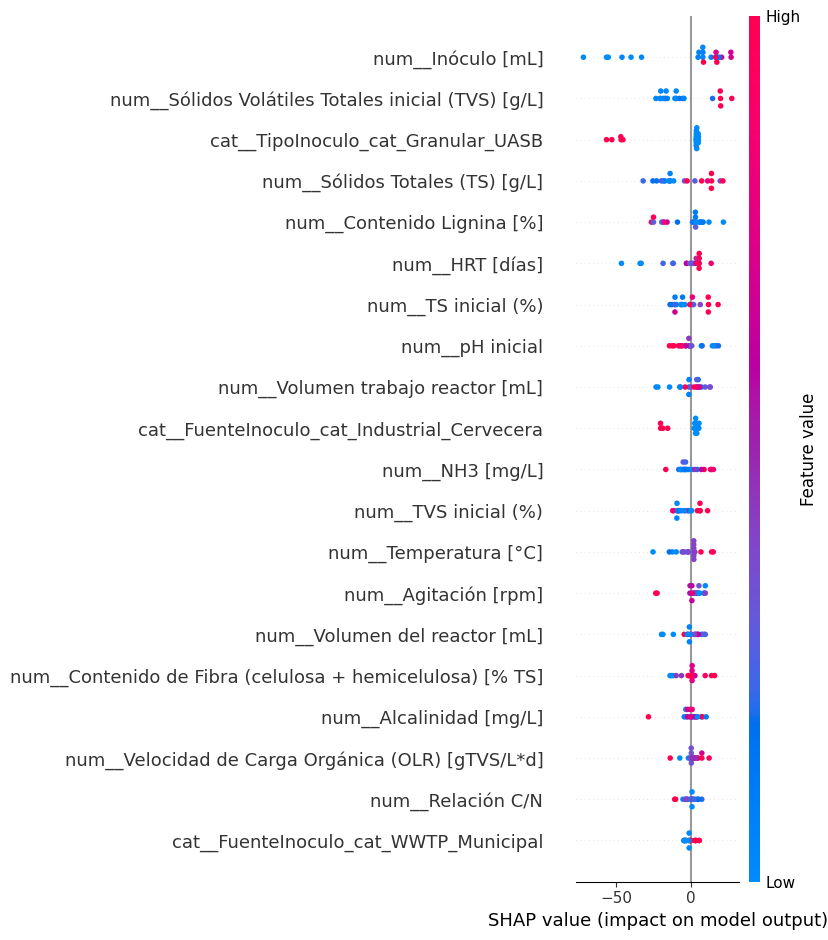


📌 SHAP — Bar Plot (Importancia de características)


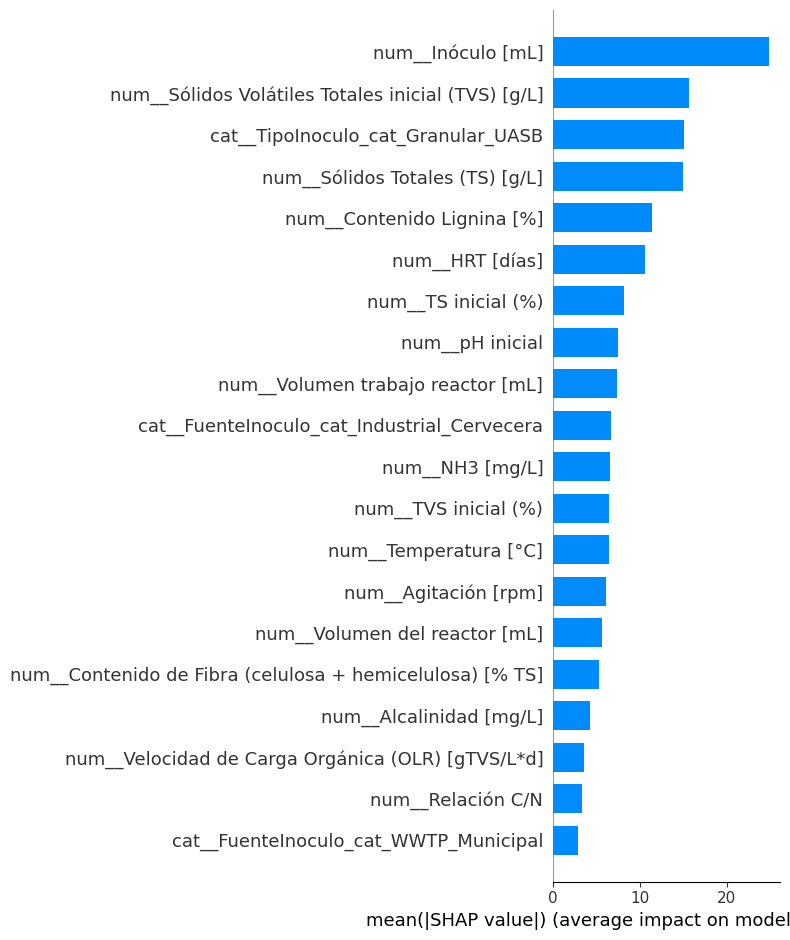


📌 SHAP — Waterfall Plot (primera muestra de X_test)


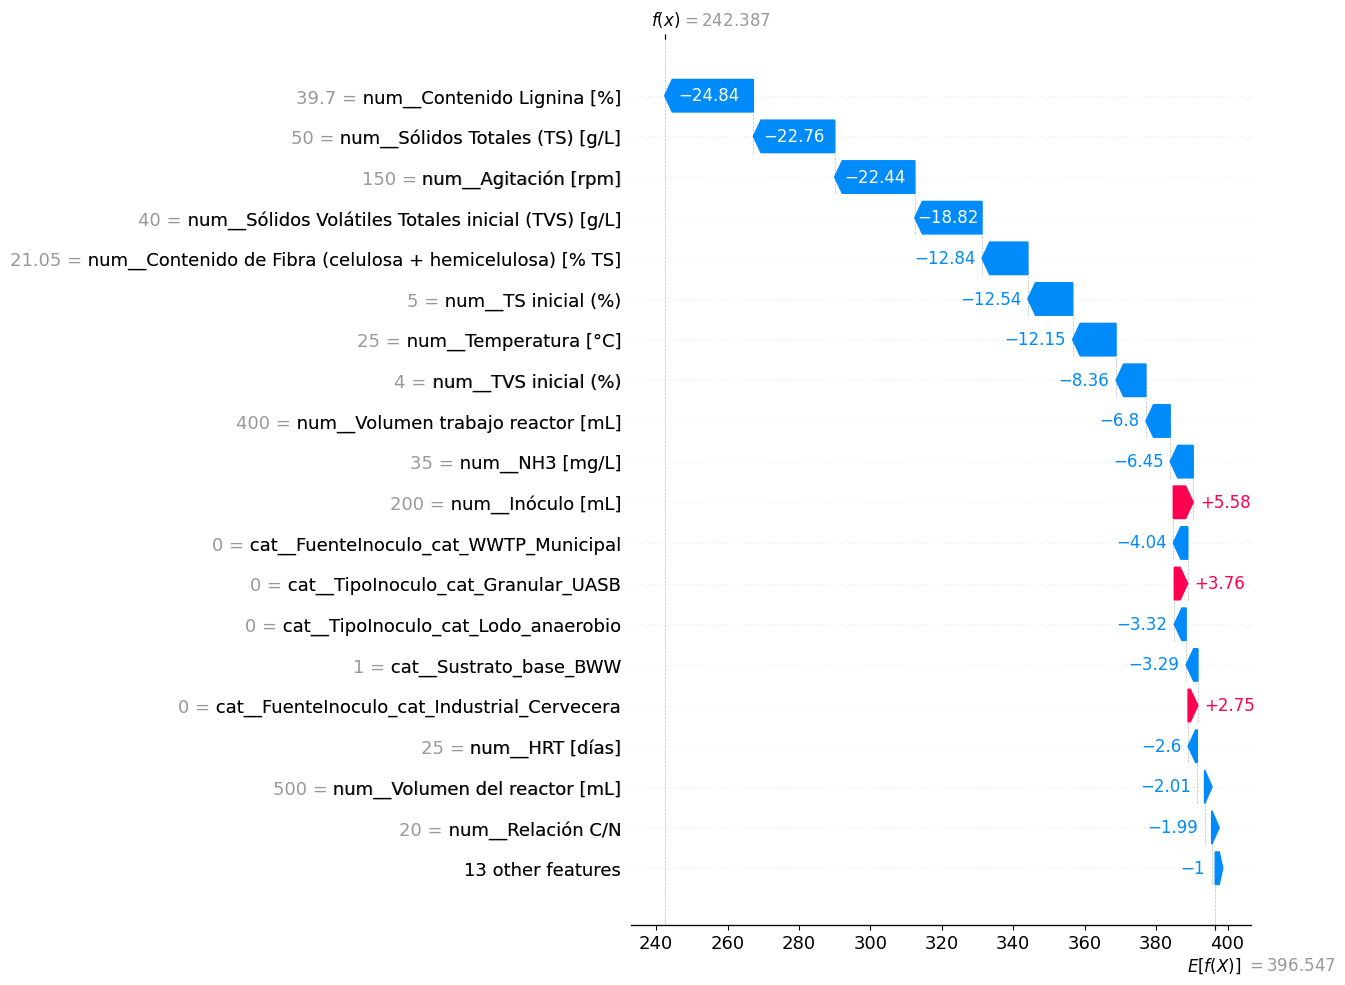

In [8]:
# ==========================================================
# ETAPA 7 — SHAP PARA MODELO 1 (Producción total biogás)
# ==========================================================

import shap
import numpy as np

print("\n=== ETAPA 7: SHAP — Producción total biogás ===\n")

# ----------------------------------------------------------
# 0) Asegurar cuál es el "mejor modelo" (salido del GridSearch)
#    En tu ETAPA 6 se llamó: best_model1 = grid1.best_estimator_
# ----------------------------------------------------------
best_model = best_model1

# ----------------------------------------------------------
# 1) Extraer preprocesador y modelo entrenado desde el Pipeline
# ----------------------------------------------------------
preprocessor = best_model.named_steps["preprocessor"]
rf_model      = best_model.named_steps["model"]

# ----------------------------------------------------------
# 2) Transformar X_test con el preprocesador
# ----------------------------------------------------------
X_test_transformed = preprocessor.transform(X_test)

# Nombres de features post-ColumnTransformer (robusto)
feature_names = preprocessor.get_feature_names_out()

print("✔ Nº de features (post-preprocess):", len(feature_names))
print("✔ Shape X_test transformado:", X_test_transformed.shape)

# ----------------------------------------------------------
# 3) Crear explicador SHAP para árboles
# ----------------------------------------------------------
explainer = shap.TreeExplainer(rf_model)

# ----------------------------------------------------------
# 4) Calcular SHAP values
#    Para RandomForestRegressor (single-output): (n_samples, n_features)
# ----------------------------------------------------------
shap_values = explainer.shap_values(X_test_transformed)

print("✔ SHAP values shape:", np.array(shap_values).shape)

# ----------------------------------------------------------
# 5) Summary plot
# ----------------------------------------------------------
print("\n📌 SHAP — Summary Plot (Producción total biogás)")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# ----------------------------------------------------------
# 6) Bar plot de importancia promedio
# ----------------------------------------------------------
print("\n📌 SHAP — Bar Plot (Importancia de características)")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

# ----------------------------------------------------------
# 7) Waterfall plot (primera muestra)
#    Usamos shap.Explanation para evitar errores del legacy
# ----------------------------------------------------------
print("\n📌 SHAP — Waterfall Plot (primera muestra de X_test)")

# expected_value suele ser escalar en regresión
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)) and len(np.array(base_value).shape) > 0:
    # si viene como array/lista de largo 1, toma el primero
    base_value = np.array(base_value).ravel()[0]

exp = shap.Explanation(
    values=shap_values[0],
    base_values=base_value,
    data=X_test_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(exp, max_display=20)


In [ ]:
# ============================================
# ETAPA 8: Modelo 2 — % REMOCIÓN TVS
# Entrenamiento + Optimización (GridSearchCV)
# ============================================

print("\n\n=== ETAPA 8: Entrenamiento y Optimización — Modelo 2 (% Remoción TVS) ===")

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1) Target (Y2)
# ---------------------------------------------------------
y_col2 = "% Remoción TVS"
y2_train = Y_train[y_col2]
y2_test  = Y_test[y_col2]

print(f"\n✔ Target seleccionado: {y_col2}")
print("   - y_train shape:", y2_train.shape)
print("   - y_test shape :", y2_test.shape)

# ---------------------------------------------------------
# 2) Pipeline base
# ---------------------------------------------------------
model2_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# ---------------------------------------------------------
# 3) Entrenar modelo base + métricas
# ---------------------------------------------------------
model2_pipeline.fit(X_train, y2_train)
y2_pred = model2_pipeline.predict(X_test)

mae2  = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2  = r2_score(y2_test, y2_pred)

print("\n📌 RESULTADOS — Modelo 2 (sin optimizar)")
print(f"MAE : {mae2:.3f}")
print(f"RMSE: {rmse2:.3f}")
print(f"R²  : {r2_2:.3f}")

# ---------------------------------------------------------
# 4) GridSearchCV
# ---------------------------------------------------------
param_grid2 = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_split": [2, 4],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid2 = GridSearchCV(
    estimator=model2_pipeline,
    param_grid=param_grid2,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid2.fit(X_train, y2_train)

best_model2 = grid2.best_estimator_

print("\n🔥 MEJORES HIPERPARÁMETROS — MODELO 2:")
print(grid2.best_params_)
print(f"🔥 Mejor R² (CV): {grid2.best_score_:.4f}")

# ---------------------------------------------------------
# 5) Evaluar modelo optimizado en test
# ---------------------------------------------------------
y2_pred_best = best_model2.predict(X_test)

mae2b  = mean_absolute_error(y2_test, y2_pred_best)
rmse2b = np.sqrt(mean_squared_error(y2_test, y2_pred_best))
r2_2b  = r2_score(y2_test, y2_pred_best)

print("\n📌 MÉTRICAS EN TEST — MODELO 2 OPTIMIZADO (% Remoción TVS)")
print(f"MAE : {mae2b:.3f}")
print(f"RMSE: {rmse2b:.3f}")
print(f"R²  : {r2_2b:.3f}")

print("\n=== ETAPA 8 COMPLETADA ===")




=== ETAPA 8: Entrenamiento y Optimización — Modelo 2 (% Remoción TVS) ===

✔ Target seleccionado: % Remoción TVS
   - y_train shape: (83,)
   - y_test shape : (21,)

📌 RESULTADOS — Modelo 2 (sin optimizar)
MAE : 7.376
RMSE: 11.657
R²  : 0.557
Fitting 5 folds for each of 72 candidates, totalling 360 fits



=== ETAPA 9: SHAP — % Remoción TVS ===

✔ Columnas expandidas: 32
✔ Shape X_test transformado: (21, 32)
✔ SHAP values shape: (21, 32)

📌 SHAP — Summary Plot (% Remoción TVS)


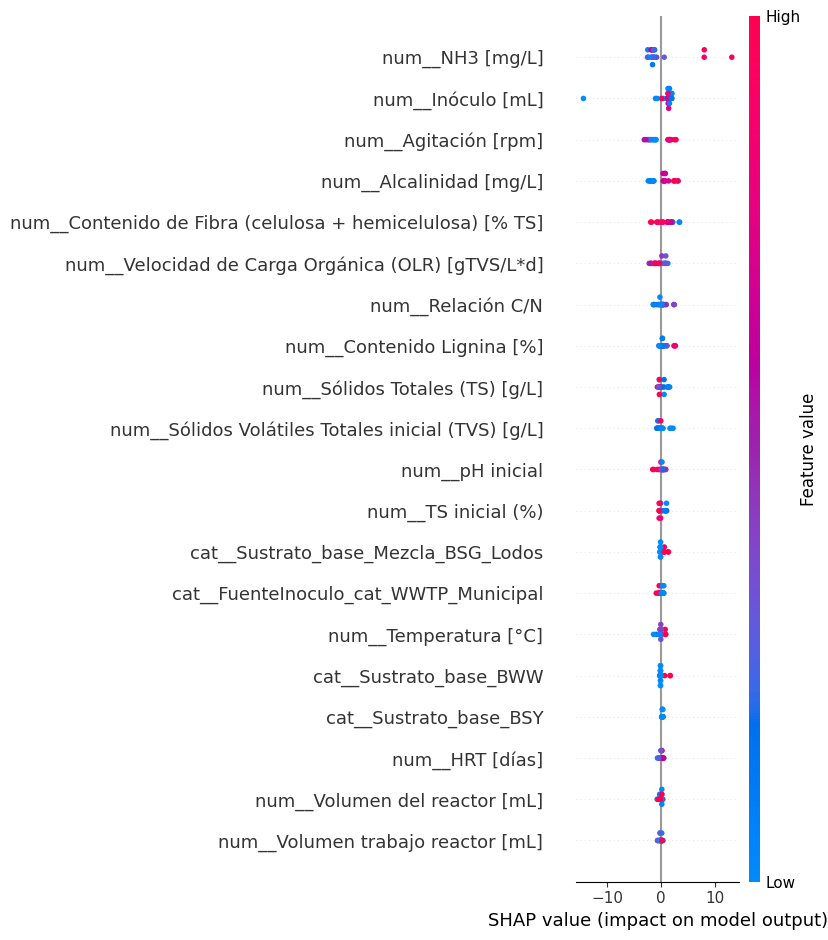


📌 SHAP — Bar Plot (% Remoción TVS)


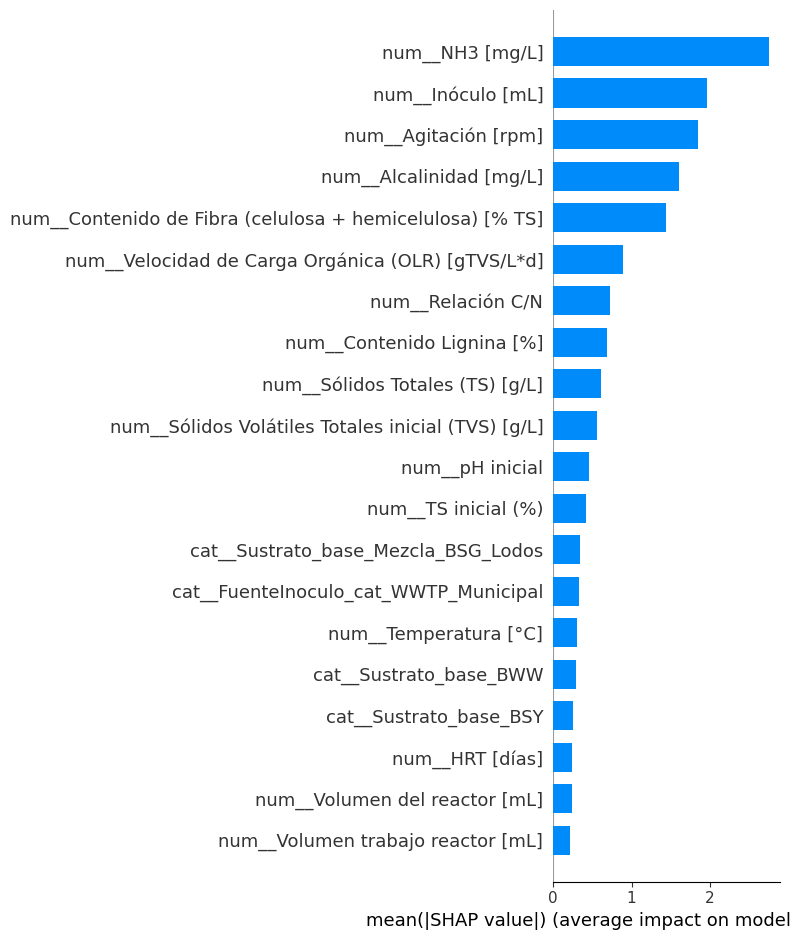


📌 SHAP — Waterfall (primer ejemplo de X_test)


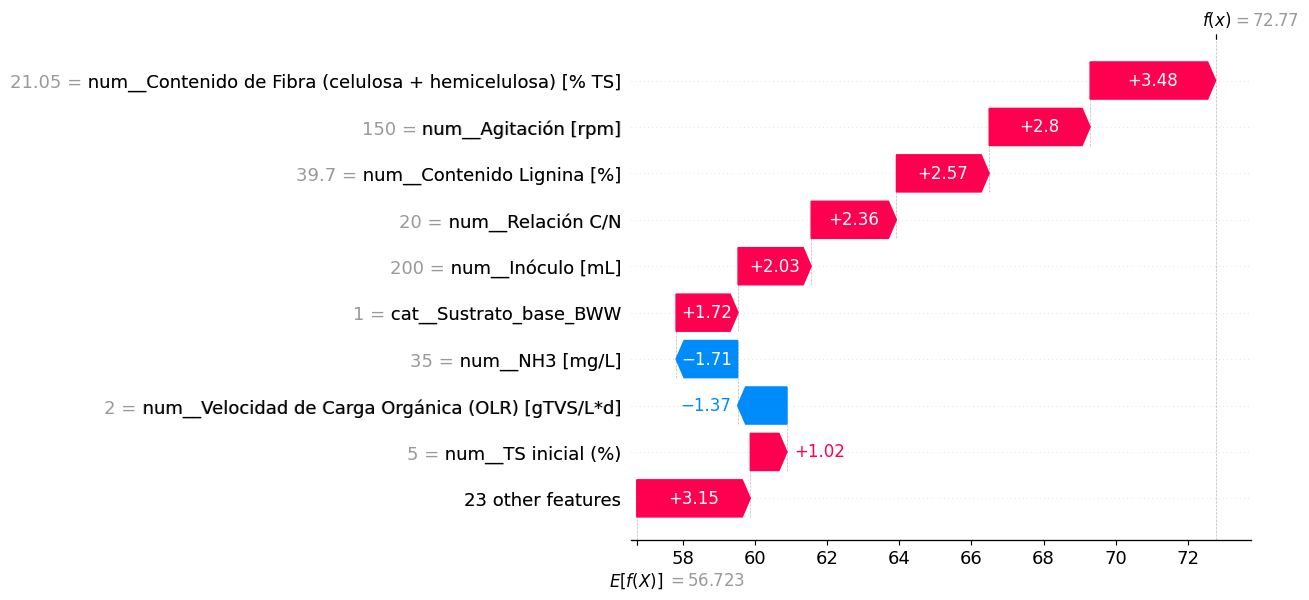

In [ ]:
# =========================================================
# ETAPA 9 — SHAP PARA MODELO 2 (% REMOCIÓN TVS)
# =========================================================

import shap
import numpy as np

print("\n=== ETAPA 9: SHAP — % Remoción TVS ===\n")

# ---------------------------------------------------------
# 1) Extraer modelo y preprocesador del pipeline ya optimizado
# ---------------------------------------------------------
best_model_2 = model2_pipeline   # << IMPORTANTE: ya está entrenado y optimizado
rf2 = best_model_2.named_steps["model"]
pre2 = best_model_2.named_steps["preprocessor"]

# ---------------------------------------------------------
# 2) Transformar X_test
# ---------------------------------------------------------
X2_test_trans = pre2.transform(X_test)
feature_names_2 = pre2.get_feature_names_out()
print("✔ Columnas expandidas:", len(feature_names_2))
print("✔ Shape X_test transformado:", X2_test_trans.shape)

# ---------------------------------------------------------
# 3) Crear Explainer SHAP
# ---------------------------------------------------------
explainer2 = shap.TreeExplainer(rf2)

# Obtener SHAP values
shap_values_2 = explainer2.shap_values(X2_test_trans)

print("✔ SHAP values shape:", np.array(shap_values_2).shape)

# Extraemos solo la salida 0 (porque es un modelo single-target)
shap_tv = shap_values_2

# ---------------------------------------------------------
# 4) SUMMARY PLOT
# ---------------------------------------------------------
print("\n📌 SHAP — Summary Plot (% Remoción TVS)")
shap.summary_plot(
    shap_tv,
    X2_test_trans,
    feature_names=feature_names_2,
    show=True
)

# ---------------------------------------------------------
# 5) BAR PLOT (importancia media absoluta)
# ---------------------------------------------------------
print("\n📌 SHAP — Bar Plot (% Remoción TVS)")
shap.summary_plot(
    shap_tv,
    X2_test_trans,
    feature_names=feature_names_2,
    plot_type="bar",
    show=True
)

# ---------------------------------------------------------
# 6) WATERFALL para la primera fila del test
# ---------------------------------------------------------
print("\n📌 SHAP — Waterfall (primer ejemplo de X_test)")

expected_val2 = explainer2.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values = shap_tv[0],
        base_values = expected_val2,
        data = X2_test_trans[0],
        feature_names = feature_names_2
    )
)


In [ ]:
# 🔧 GRID DE HIPERPARÁMETROS PARA RANDOM FOREST
param_grid_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 12, 16],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 4, 6],
    "model__min_samples_leaf": [1, 2]
}


In [ ]:
# ============================================
# ETAPA 10: Entrenamiento y Optimización
# Modelo 3 — Porcentaje de CH4 en biogás (%)
# ============================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("\n=== ETAPA 10: Entrenamiento y Optimización — Modelo 3 (Porcentaje de CH₄ en biogás) ===\n")

# ---- 10.1 DEFINIR VARIABLE DE SALIDA ----
target3 = "Porcentaje de CH4 en biogás (%)"
y3 = Y[target3]
y3_train = y3.loc[X_train.index]
y3_test = y3.loc[X_test.index]

# ---- 10.2 ENTRENAMIENTO DEL MODELO BASE ----
model3_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

model3_pipeline.fit(X_train, y3_train)
y3_pred = model3_pipeline.predict(X_test)

mae3 = mean_absolute_error(y3_test, y3_pred)
rmse3 = np.sqrt(mean_squared_error(y3_test, y3_pred))
r2_3 = r2_score(y3_test, y3_pred)

print("📌 RESULTADOS — Modelo 3 (sin optimizar)")
print(f"MAE : {mae3:.3f}")
print(f"RMSE: {rmse3:.3f}")
print(f"R²  : {r2_3:.3f}")

# ---- 10.3 OPTIMIZACIÓN CON GRIDSEARCH ----
rf3 = RandomForestRegressor(random_state=42)

grid3 = GridSearchCV(
    estimator=Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf3)
    ]),
    param_grid=param_grid_rf,   # mismo grid que los modelos anteriores
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid3.fit(X_train, y3_train)

print("\n🔥 MEJORES HIPERPARÁMETROS MODELO 3:")
print(grid3.best_params_)

# ---- 10.4 REENTRENAR CON MEJORES PARÁMETROS ----
best_model_3 = grid3.best_estimator_

y3_pred_best = best_model_3.predict(X_test)

mae3b = mean_absolute_error(y3_test, y3_pred_best)
rmse3b = np.sqrt(mean_squared_error(y3_test, y3_pred_best))
r2_3b = r2_score(y3_test, y3_pred_best)

print("\n📌 MÉTRICAS MODELO 3 OPTIMIZADO — Porcentaje de CH4")
print(f"MAE : {mae3b:.3f}")
print(f"RMSE: {rmse3b:.3f}")
print(f"R²  : {r2_3b:.3f}")

print("\n=== ETAPA 10 COMPLETADA ===")



=== ETAPA 10: Entrenamiento y Optimización — Modelo 3 (Porcentaje de CH₄ en biogás) ===

📌 RESULTADOS — Modelo 3 (sin optimizar)
MAE : 3.971
RMSE: 7.613
R²  : 0.681
Fitting 5 folds for each of 108 candidates, totalling 540 fits

🔥 MEJORES HIPERPARÁMETROS MODELO 3:
{'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 600}

📌 MÉTRICAS MODELO 3 OPTIMIZADO — Porcentaje de CH4
MAE : 2.912
RMSE: 5.021
R²  : 0.861

=== ETAPA 10 COMPLETADA ===




=== ETAPA 11: SHAP — Porcentaje de CH₄ en biogás ===
✔ Shape X_test transformado: (21, 32)
✔ Columnas expandidas: 32
✔ SHAP values shape: (21, 32)

📌 SHAP — Summary Plot (Porcentaje de CH₄ en biogás)


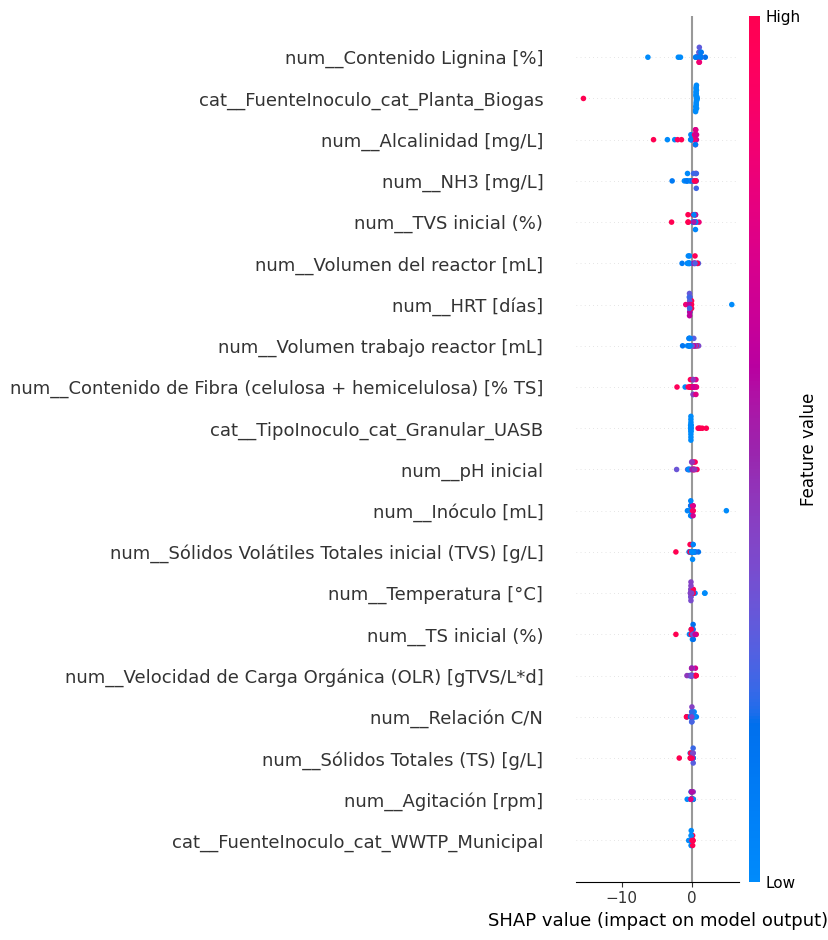


📌 SHAP — Bar Plot (Importancia media absoluta — Porcentaje de CH₄)


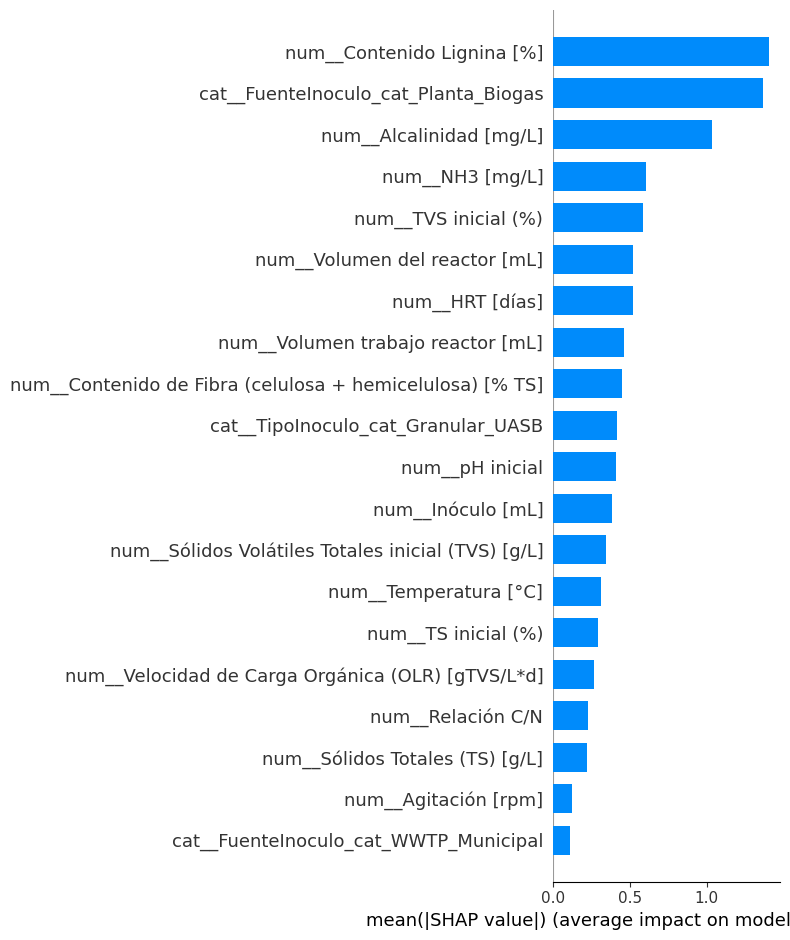


📌 SHAP — Waterfall (primer ejemplo de X_test)


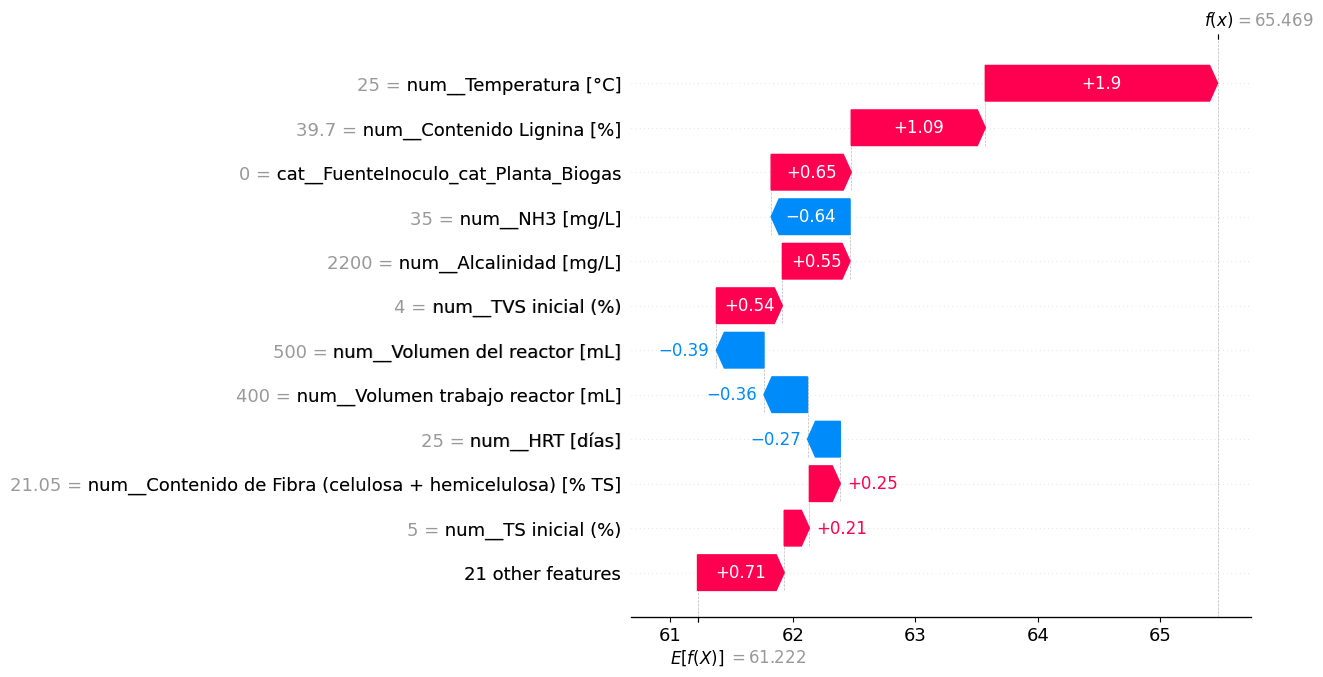


=== ETAPA 11 COMPLETADA ===


In [ ]:
# ============================================
# ETAPA 11: SHAP — Modelo 3 (% CH₄ en biogás) [FIX ROBUSTO]
# ============================================

import shap
import numpy as np

print("\n\n=== ETAPA 11: SHAP — Porcentaje de CH₄ en biogás ===")

# 1) Verificar que existe best_model_3
try:
    best_model_3
except NameError:
    raise RuntimeError("⚠️ 'best_model_3' no está definido. Ejecuta la ETAPA 10 antes de esta.")

# 2) Extraer modelo y preprocesador desde el pipeline
rf3_best = best_model_3.named_steps["model"]
preprocessor_3 = best_model_3.named_steps["preprocessor"]

# 3) Transformar X_test con el preprocesador del modelo 3
X_test_transformed = preprocessor_3.transform(X_test)

# Convertir a denso si viene sparse
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print(f"✔ Shape X_test transformado: {X_test_transformed.shape}")

# 4) Obtener feature names DEL PREPROCESSOR (sin hardcodear)
#    Esto evita el error de mismatch con feature_names_in_
try:
    feature_names = preprocessor_3.get_feature_names_out()
    feature_names = feature_names.tolist()
except Exception as e:
    # Fallback (por si alguna versión rara no soporta get_feature_names_out)
    feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]
    print("⚠ No se pudo extraer feature_names desde preprocessor_3. Usando nombres genéricos.")
    print("   Detalle:", repr(e))

print(f"✔ Columnas expandidas: {len(feature_names)}")

# 5) Crear el explainer SHAP (árboles)
explainer_3 = shap.TreeExplainer(rf3_best)

# 6) Calcular SHAP values
shap_values_3 = explainer_3.shap_values(X_test_transformed)

# En algunos casos shap devuelve lista; normalizamos
if isinstance(shap_values_3, list):
    # Para single-output a veces viene [array]
    if len(shap_values_3) == 1:
        shap_ch4 = shap_values_3[0]
    else:
        # Si fuera multioutput (no debería aquí), tomamos el primero
        shap_ch4 = shap_values_3[0]
else:
    shap_ch4 = shap_values_3

print(f"✔ SHAP values shape: {np.array(shap_ch4).shape}")

# 7) SUMMARY PLOT (beeswarm)
print("\n📌 SHAP — Summary Plot (Porcentaje de CH₄ en biogás)")
shap.summary_plot(
    shap_ch4,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

# 8) BAR PLOT (importancia media absoluta)
print("\n📌 SHAP — Bar Plot (Importancia media absoluta — Porcentaje de CH₄)")
shap.summary_plot(
    shap_ch4,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# 9) WATERFALL PLOT para la primera observación (forma moderna)
print("\n📌 SHAP — Waterfall (primer ejemplo de X_test)")

expected_val = explainer_3.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[0]

exp = shap.Explanation(
    values=shap_ch4[0],
    base_values=expected_val,
    data=X_test_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(exp, max_display=12)

print("\n=== ETAPA 11 COMPLETADA ===")


In [ ]:
# ============================================
# ETAPA — Guardar Modelos y Metadata (FIX)
# ============================================

import joblib
import json
import os

# Carpeta donde se guardarán los modelos
save_dir = "/content/drive/MyDrive/TESIS_MODELOS"
os.makedirs(save_dir, exist_ok=True)

print("📁 Carpeta de guardado:", save_dir)

# ------------------------------------------------
# 1) Guardar Modelos (si existen en memoria)
# ------------------------------------------------
if 'best_model_1' in globals():
    joblib.dump(best_model_1, f"{save_dir}/modelo1_biogas.pkl")
    print("✔ Modelo 1 guardado como modelo1_biogas.pkl")
else:
    print("⚠ Modelo 1 no está en memoria (best_model_1 no existe).")

if 'best_model_2' in globals():
    joblib.dump(best_model_2, f"{save_dir}/modelo2_tvs.pkl")
    print("✔ Modelo 2 guardado como modelo2_tvs.pkl")
else:
    print("⚠ Modelo 2 no está en memoria (best_model_2 no existe).")

if 'best_model_3' in globals():
    joblib.dump(best_model_3, f"{save_dir}/modelo3_ch4.pkl")
    print("✔ Modelo 3 guardado como modelo3_ch4.pkl")
else:
    print("⚠ Modelo 3 no está en memoria (best_model_3 no existe).")

# ------------------------------------------------
# 2) Guardar Metadata útil para la interfaz
# ------------------------------------------------

# Detectar cuál columna categórica de sustrato está vigente
if "Sustrato_base" in df.columns:
    sustrato_col = "Sustrato_base"
elif "Sustrato_cat" in df.columns:
    sustrato_col = "Sustrato_cat"
else:
    raise KeyError("❌ No se encontró ni 'Sustrato_base' ni 'Sustrato_cat' en df. Revisa la ETAPA 1.")

print(f"🧩 Columna de sustrato detectada para metadata: {sustrato_col}")

# Validar que existan las otras categóricas (por si acaso)
for c in ["TipoInoculo_cat", "FuenteInoculo_cat"]:
    if c not in df.columns:
        raise KeyError(f"❌ Falta la columna categórica '{c}' en df. Revisa tu ETAPA 1.")

metadata = {
    "categorias": {
        sustrato_col: df[sustrato_col].dropna().unique().tolist(),
        "TipoInoculo_cat": df["TipoInoculo_cat"].dropna().unique().tolist(),
        "FuenteInoculo_cat": df["FuenteInoculo_cat"].dropna().unique().tolist(),
    },
    "columnas_X": X.columns.tolist(),
    "columnas_Y": Y.columns.tolist()
}

with open(f"{save_dir}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✔ Metadata guardada como metadata.json")

print("\n🎉 TODOS LOS ARCHIVOS FUERON GUARDADOS CON ÉXITO")
print(f"📁 Carpeta: {save_dir}")


📁 Carpeta de guardado: /content/drive/MyDrive/TESIS_MODELOS
⚠ Modelo 1 no está en memoria (best_model_1 no existe).
✔ Modelo 2 guardado como modelo2_tvs.pkl
✔ Modelo 3 guardado como modelo3_ch4.pkl
🧩 Columna de sustrato detectada para metadata: Sustrato_base
✔ Metadata guardada como metadata.json

🎉 TODOS LOS ARCHIVOS FUERON GUARDADOS CON ÉXITO
📁 Carpeta: /content/drive/MyDrive/TESIS_MODELOS


In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
#   BioGas Predictor v1.1 — Random Forest (compatible)
#   FIX: theme va en Blocks (tu versión de Gradio no acepta theme en launch)
# ============================================================

!pip install gradio -q

import gradio as gr
import joblib
import json
import numpy as np
import pandas as pd

# ============================================================
#   1) CARGAR MODELOS Y METADATA
# ============================================================

ruta = "/content/drive/MyDrive/TESIS_MODELOS"

modelo1 = joblib.load(f"{ruta}/modelo1_biogas.pkl")
modelo2 = joblib.load(f"{ruta}/modelo2_tvs.pkl")
modelo3 = joblib.load(f"{ruta}/modelo3_ch4.pkl")

with open(f"{ruta}/metadata.json", "r") as f:
    meta = json.load(f)

categorias = meta["categorias"]
columnas_X = meta["columnas_X"]

# Detectar nombre real de la columna de sustrato (Sustrato_base o Sustrato_cat)
if "Sustrato_base" in categorias:
    sustrato_key = "Sustrato_base"
elif "Sustrato_cat" in categorias:
    sustrato_key = "Sustrato_cat"
else:
    raise KeyError("❌ En metadata.json no está 'Sustrato_base' ni 'Sustrato_cat' dentro de categorias.")

print(f"🧩 Sustrato detectado en metadata: {sustrato_key}")

# ============================================================
#   2) RANGOS NUMÉRICOS (intenta leer de df si existe)
# ============================================================

def _rango(col, default_min, default_max, step):
    """
    Intenta sacar min/max desde df[col] si df existe y tiene la columna.
    Si no, usa defaults.
    """
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame) and col in globals()["df"].columns:
        serie = pd.to_numeric(globals()["df"][col], errors="coerce").dropna()
        if len(serie) > 0:
            mn = float(serie.min())
            mx = float(serie.max())
            pad = 0.10 * (mx - mn) if mx > mn else 1.0
            return (max(0, mn - pad), mx + pad, step)
    return (default_min, default_max, step)

# Defaults grandes si df no está en memoria
r_vol_reactor = _rango("Volumen del reactor [mL]", 50, 30000, 10)
r_vol_trabajo = _rango("Volumen trabajo reactor [mL]", 50, 30000, 10)
r_inoculo     = _rango("Inóculo [mL]", 1, 20000, 1)
r_ts_inicial  = _rango("TS inicial (%)", 0, 40, 0.1)
r_ts_gl       = _rango("Sólidos Totales (TS) [g/L]", 0, 400, 1)
r_tvs_pct     = _rango("TVS inicial (%)", 0, 40, 0.1)
r_tvs_gl      = _rango("Sólidos Volátiles Totales inicial (TVS) [g/L]", 0, 400, 1)
r_cn          = _rango("Relación C/N", 1, 60, 0.1)
r_lignina     = _rango("Contenido Lignina [%]", 0, 60, 0.1)
r_fibra       = _rango("Contenido de Fibra (celulosa + hemicelulosa) [% TS]", 0, 100, 0.1)
r_nh3         = _rango("NH3 [mg/L]", 0, 8000, 10)
r_temp        = _rango("Temperatura [°C]", 5, 80, 1)
r_hrt         = _rango("HRT [días]", 0.5, 120, 0.5)
r_ph          = _rango("pH inicial", 3, 10, 0.01)
r_alc         = _rango("Alcalinidad [mg/L]", 0, 15000, 10)
r_olr         = _rango("Velocidad de Carga Orgánica (OLR) [gTVS/L*d]", 0.01, 25, 0.1)
r_agit        = _rango("Agitación [rpm]", 0, 1000, 10)

# ============================================================
#   3) FUNCIÓN DE PREDICCIÓN (usa sustrato_key correcto)
# ============================================================

def predecir_biogas(
    Sustrato_val, TipoInoculo_cat, FuenteInoculo_cat,
    Vol_reactor, Vol_trabajo, Inoculo, TS_inicial,
    TS_gL, TVS_inicial_pct, TVS_inicial_gL,
    CN_ratio, Lignina, Fibra, NH3,
    Temp, HRT, pH_ini, Alcalinidad,
    OLR, Agitacion
):
    datos = {
        sustrato_key: [Sustrato_val],  # <- clave correcta
        "TipoInoculo_cat": [TipoInoculo_cat],
        "FuenteInoculo_cat": [FuenteInoculo_cat],
        "Volumen del reactor [mL]": [Vol_reactor],
        "Volumen trabajo reactor [mL]": [Vol_trabajo],
        "Inóculo [mL]": [Inoculo],
        "TS inicial (%)": [TS_inicial],
        "Sólidos Totales (TS) [g/L]": [TS_gL],
        "TVS inicial (%)": [TVS_inicial_pct],
        "Sólidos Volátiles Totales inicial (TVS) [g/L]": [TVS_inicial_gL],
        "Relación C/N": [CN_ratio],
        "Contenido Lignina [%]": [Lignina],
        "Contenido de Fibra (celulosa + hemicelulosa) [% TS]": [Fibra],
        "NH3 [mg/L]": [NH3],
        "Temperatura [°C]": [Temp],
        "HRT [días]": [HRT],
        "pH inicial": [pH_ini],
        "Alcalinidad [mg/L]": [Alcalinidad],
        "Velocidad de Carga Orgánica (OLR) [gTVS/L*d]": [OLR],
        "Agitación [rpm]": [Agitacion]
    }

    df_in = pd.DataFrame(datos)

    pred1 = float(modelo1.predict(df_in)[0])
    pred2 = float(modelo2.predict(df_in)[0])
    pred3 = float(modelo3.predict(df_in)[0])

    return (
        f"{pred1:.2f} mL/gVS",
        f"{pred2:.2f} %",
        f"{pred3:.2f} % CH₄"
    )

# ============================================================
#   4) CONSTRUIR INTERFAZ (theme en Blocks)
# ============================================================

with gr.Blocks(
    theme=gr.themes.Base(primary_hue="green", neutral_hue="gray")
) as interfaz:

    gr.Markdown(f"""
    # ⚙️ **BioGas Predictor v1.1 — Modelo Random Forest**
    ### Predicción de biogás, remoción de TVS y %CH₄
    **Sustrato detectado:** `{sustrato_key}`
    """)

    with gr.Row():
        with gr.Column():

            sustrato_input = gr.Dropdown(
                choices=categorias[sustrato_key],
                label=sustrato_key,
            )

            inoculo_tipo_input = gr.Dropdown(
                choices=categorias["TipoInoculo_cat"],
                label="TipoInoculo_cat",
            )

            fuente_input = gr.Dropdown(
                choices=categorias["FuenteInoculo_cat"],
                label="FuenteInoculo_cat",
            )

            Vol_reactor = gr.Slider(*r_vol_reactor, label="Volumen del reactor [mL]")
            Vol_trabajo = gr.Slider(*r_vol_trabajo, label="Volumen trabajo reactor [mL]")
            Inoculo     = gr.Slider(*r_inoculo, label="Inóculo [mL]")
            TS_inicial  = gr.Slider(*r_ts_inicial, label="TS inicial (%)")
            TS_gL       = gr.Slider(*r_ts_gl, label="Sólidos Totales (TS) [g/L]")
            TVS_pct     = gr.Slider(*r_tvs_pct, label="TVS inicial (%)")
            TVS_gL      = gr.Slider(*r_tvs_gl, label="Sólidos Volátiles Totales inicial (TVS) [g/L]")
            CN_ratio    = gr.Slider(*r_cn, label="Relación C/N")
            Lignina     = gr.Slider(*r_lignina, label="Contenido Lignina [%]")
            Fibra       = gr.Slider(*r_fibra, label="Contenido de Fibra (celulosa + hemicelulosa) [% TS]")
            NH3_input   = gr.Slider(*r_nh3, label="NH3 [mg/L]")
            Temp        = gr.Slider(*r_temp, label="Temperatura [°C]")
            HRT         = gr.Slider(*r_hrt, label="HRT [días]")
            pH_ini      = gr.Slider(*r_ph, label="pH inicial")
            Alcalinidad = gr.Slider(*r_alc, label="Alcalinidad [mg/L]")
            OLR         = gr.Slider(*r_olr, label="Velocidad de Carga Orgánica (OLR) [gTVS/L*d]")
            Agitacion   = gr.Slider(*r_agit, label="Agitación [rpm]")

        with gr.Column():

            boton = gr.Button("🔍 Predecir")

            salida_biogas = gr.Textbox(label="Producción total biogás [mL/g VS]")
            salida_tvs    = gr.Textbox(label="% Remoción TVS")
            salida_ch4    = gr.Textbox(label="% CH₄ en biogás")

            boton.click(
                predecir_biogas,
                inputs=[
                    sustrato_input, inoculo_tipo_input, fuente_input,
                    Vol_reactor, Vol_trabajo, Inoculo, TS_inicial,
                    TS_gL, TVS_pct, TVS_gL, CN_ratio, Lignina, Fibra,
                    NH3_input, Temp, HRT, pH_ini, Alcalinidad, OLR, Agitacion
                ],
                outputs=[salida_biogas, salida_tvs, salida_ch4]
            )

interfaz.launch(debug=True)
